In [7]:
## PROBA_RF
import numpy as np
import pandas as pd
import geopandas as gpd
import joblib

# ---------- 1) Load test ----------
test_gdf = gpd.read_file("data/test.geojson")

# ---------- 2) Feature engineering (IDENTIQUE au training) ----------
def add_geometry_features(gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    if gdf.crs and gdf.crs.is_geographic:
        gdf = gdf.to_crs("EPSG:3857")

    gdf = gdf[gdf.geometry.notnull() & gdf.is_valid]
    geom = gdf.geometry
    out = pd.DataFrame(index=gdf.index)

    out["area"] = geom.area
    out["perimeter"] = geom.length

    bounds = geom.bounds
    out["bbox_w"] = bounds["maxx"] - bounds["minx"]
    out["bbox_h"] = bounds["maxy"] - bounds["miny"]
    out["bbox_aspect"] = out["bbox_w"] / (out["bbox_h"] + 1e-9)

    out["compactness"] = 4 * np.pi * out["area"] / ((out["perimeter"] ** 2) + 1e-9)
    hull_area = geom.convex_hull.area
    out["convexity_area_ratio"] = out["area"] / (hull_area + 1e-9)

    def n_vertices(g):
        try:
            return len(g.exterior.coords)
        except Exception:
            return 0

    out["n_vertices"] = geom.apply(n_vertices)
    return out


def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for k in range(1, 6):
        r = out[f"img_red_mean_date{k}"]
        g = out[f"img_green_mean_date{k}"]
        b = out[f"img_blue_mean_date{k}"]
        s = r + g + b + 1e-9
        out[f"bright_mean_date{k}"] = s / 3.0
        out[f"r_ratio_date{k}"] = r / s
        out[f"g_ratio_date{k}"] = g / s
        out[f"b_ratio_date{k}"] = b / s

    for c in ["red", "green", "blue"]:
        out[f"{c}_mean_delta_1_5"] = out[f"img_{c}_mean_date5"] - out[f"img_{c}_mean_date1"]
        out[f"{c}_std_delta_1_5"]  = out[f"img_{c}_std_date5"]  - out[f"img_{c}_std_date1"]

    for c in ["red", "green", "blue"]:
        means = np.vstack([out[f"img_{c}_mean_date{k}"].values for k in range(1, 6)]).T
        out[f"{c}_mean_volatility"] = means.std(axis=1)

    status_cols = [f"change_status_date{i}" for i in range(0, 5)]
    statuses = out[status_cols].astype(str)

    out["status_n_unique"] = statuses.nunique(axis=1)

    def count_transitions(row):
        seq = row.values
        return sum(seq[i] != seq[i-1] for i in range(1, len(seq)))

    out["status_transitions"] = statuses.apply(count_transitions, axis=1)
    return out


def extract_date_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    date_cols = []

    for col in df.columns:
        v = df[col].iloc[0]
        if isinstance(v, str) and ("-" in v or "/" in v):
            date_cols.append(col)

    for col in date_cols:
        parsed = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
        df[f"{col}_year"] = parsed.dt.year
        df[f"{col}_month"] = parsed.dt.month
        df[f"{col}_day"] = parsed.dt.day

    return df

def to_dense(X):
    return X.toarray() if hasattr(X, 'toarray') else X


# ---------- 3) Rebuild test features EXACTEMENT comme avant ----------
test_X = test_gdf.copy()

test_geom = add_geometry_features(test_gdf.loc[test_X.index])
test_feat = pd.concat([test_X.drop(columns=["geometry"]), test_geom], axis=1)

test_feat = add_temporal_features(test_feat)
test_feat = extract_date_features(test_feat)

# gérer les inf
test_feat.replace([np.inf, -np.inf], np.nan, inplace=True)

# ---------- 4) Load model ----------
print("Loading saved model...")
best_model = joblib.load("model/model_rf.joblib")

# ---------- 5) Predict probabilities ----------
proba = best_model.predict_proba(test_feat)

# récupérer les labels dans l’ordre du modèle
class_labels = best_model.classes_

# ---------- 6) Save submission ----------
sub = pd.DataFrame(proba, columns=[f"proba_class_{c}" for c in class_labels])
sub.insert(0, "Id", np.arange(0, len(proba)))

sub.to_csv("Proba/PROBA_rf.csv", index=False)
print("Submission written: PROBA_rf.csv")



Loading saved model...
Submission written: PROBA_rf.csv


In [8]:
## PROBA_BOOST
import numpy as np
import pandas as pd
import geopandas as gpd
import joblib

# ---------- 1) Load test ----------
test_gdf = gpd.read_file("data/test.geojson")

# ---------- 2) Feature engineering (IDENTIQUE au training) ----------
def add_geometry_features(gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    if gdf.crs and gdf.crs.is_geographic:
        gdf = gdf.to_crs("EPSG:3857")

    gdf = gdf[gdf.geometry.notnull() & gdf.is_valid]
    geom = gdf.geometry
    out = pd.DataFrame(index=gdf.index)

    out["area"] = geom.area
    out["perimeter"] = geom.length

    bounds = geom.bounds
    out["bbox_w"] = bounds["maxx"] - bounds["minx"]
    out["bbox_h"] = bounds["maxy"] - bounds["miny"]
    out["bbox_aspect"] = out["bbox_w"] / (out["bbox_h"] + 1e-9)

    out["compactness"] = 4 * np.pi * out["area"] / ((out["perimeter"] ** 2) + 1e-9)
    hull_area = geom.convex_hull.area
    out["convexity_area_ratio"] = out["area"] / (hull_area + 1e-9)

    def n_vertices(g):
        try:
            return len(g.exterior.coords)
        except Exception:
            return 0

    out["n_vertices"] = geom.apply(n_vertices)
    return out


def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for k in range(1, 6):
        r = out[f"img_red_mean_date{k}"]
        g = out[f"img_green_mean_date{k}"]
        b = out[f"img_blue_mean_date{k}"]
        s = r + g + b + 1e-9
        out[f"bright_mean_date{k}"] = s / 3.0
        out[f"r_ratio_date{k}"] = r / s
        out[f"g_ratio_date{k}"] = g / s
        out[f"b_ratio_date{k}"] = b / s

    for c in ["red", "green", "blue"]:
        out[f"{c}_mean_delta_1_5"] = out[f"img_{c}_mean_date5"] - out[f"img_{c}_mean_date1"]
        out[f"{c}_std_delta_1_5"]  = out[f"img_{c}_std_date5"]  - out[f"img_{c}_std_date1"]

    for c in ["red", "green", "blue"]:
        means = np.vstack([out[f"img_{c}_mean_date{k}"].values for k in range(1, 6)]).T
        out[f"{c}_mean_volatility"] = means.std(axis=1)

    status_cols = [f"change_status_date{i}" for i in range(0, 5)]
    statuses = out[status_cols].astype(str)

    out["status_n_unique"] = statuses.nunique(axis=1)

    def count_transitions(row):
        seq = row.values
        return sum(seq[i] != seq[i-1] for i in range(1, len(seq)))

    out["status_transitions"] = statuses.apply(count_transitions, axis=1)
    return out


def extract_date_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    date_cols = []

    for col in df.columns:
        v = df[col].iloc[0]
        if isinstance(v, str) and ("-" in v or "/" in v):
            date_cols.append(col)

    for col in date_cols:
        parsed = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
        df[f"{col}_year"] = parsed.dt.year
        df[f"{col}_month"] = parsed.dt.month
        df[f"{col}_day"] = parsed.dt.day

    return df

def to_dense(X):
    return X.toarray() if hasattr(X, 'toarray') else X


# ---------- 3) Rebuild test features EXACTEMENT comme avant ----------
test_X = test_gdf.copy()

test_geom = add_geometry_features(test_gdf.loc[test_X.index])
test_feat = pd.concat([test_X.drop(columns=["geometry"]), test_geom], axis=1)

test_feat = add_temporal_features(test_feat)
test_feat = extract_date_features(test_feat)

# gérer les inf
test_feat.replace([np.inf, -np.inf], np.nan, inplace=True)

# ---------- 4) Load model ----------
print("Loading saved model...")
best_model = joblib.load("model/model_boost.joblib")

# ---------- 5) Predict probabilities ----------
proba = best_model.predict_proba(test_feat)

# récupérer les labels dans l’ordre du modèle
class_labels = best_model.classes_

# ---------- 6) Save submission ----------
sub = pd.DataFrame(proba, columns=[f"proba_class_{c}" for c in class_labels])
sub.insert(0, "Id", np.arange(0, len(proba)))

sub.to_csv("Proba/PROBA_boost.csv", index=False)
print("Submission written: PROBA_boost.csv")



Loading saved model...
Submission written: PROBA_boost.csv


In [9]:
## PROBA_RF_PCA
import numpy as np
import pandas as pd
import geopandas as gpd
import joblib

# ---------- 1) Load test ----------
test_gdf = gpd.read_file("data/test.geojson")

# ---------- 2) Feature engineering (IDENTIQUE au training) ----------
def add_geometry_features(gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    if gdf.crs and gdf.crs.is_geographic:
        gdf = gdf.to_crs("EPSG:3857")

    gdf = gdf[gdf.geometry.notnull() & gdf.is_valid]
    geom = gdf.geometry
    out = pd.DataFrame(index=gdf.index)

    out["area"] = geom.area
    out["perimeter"] = geom.length

    bounds = geom.bounds
    out["bbox_w"] = bounds["maxx"] - bounds["minx"]
    out["bbox_h"] = bounds["maxy"] - bounds["miny"]
    out["bbox_aspect"] = out["bbox_w"] / (out["bbox_h"] + 1e-9)

    out["compactness"] = 4 * np.pi * out["area"] / ((out["perimeter"] ** 2) + 1e-9)
    hull_area = geom.convex_hull.area
    out["convexity_area_ratio"] = out["area"] / (hull_area + 1e-9)

    def n_vertices(g):
        try:
            return len(g.exterior.coords)
        except Exception:
            return 0

    out["n_vertices"] = geom.apply(n_vertices)
    return out


def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for k in range(1, 6):
        r = out[f"img_red_mean_date{k}"]
        g = out[f"img_green_mean_date{k}"]
        b = out[f"img_blue_mean_date{k}"]
        s = r + g + b + 1e-9
        out[f"bright_mean_date{k}"] = s / 3.0
        out[f"r_ratio_date{k}"] = r / s
        out[f"g_ratio_date{k}"] = g / s
        out[f"b_ratio_date{k}"] = b / s

    for c in ["red", "green", "blue"]:
        out[f"{c}_mean_delta_1_5"] = out[f"img_{c}_mean_date5"] - out[f"img_{c}_mean_date1"]
        out[f"{c}_std_delta_1_5"]  = out[f"img_{c}_std_date5"]  - out[f"img_{c}_std_date1"]

    for c in ["red", "green", "blue"]:
        means = np.vstack([out[f"img_{c}_mean_date{k}"].values for k in range(1, 6)]).T
        out[f"{c}_mean_volatility"] = means.std(axis=1)

    status_cols = [f"change_status_date{i}" for i in range(0, 5)]
    statuses = out[status_cols].astype(str)

    out["status_n_unique"] = statuses.nunique(axis=1)

    def count_transitions(row):
        seq = row.values
        return sum(seq[i] != seq[i-1] for i in range(1, len(seq)))

    out["status_transitions"] = statuses.apply(count_transitions, axis=1)
    return out


def extract_date_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    date_cols = []

    for col in df.columns:
        v = df[col].iloc[0]
        if isinstance(v, str) and ("-" in v or "/" in v):
            date_cols.append(col)

    for col in date_cols:
        parsed = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
        df[f"{col}_year"] = parsed.dt.year
        df[f"{col}_month"] = parsed.dt.month
        df[f"{col}_day"] = parsed.dt.day

    return df

def to_dense(X):
    return X.toarray() if hasattr(X, 'toarray') else X


# ---------- 3) Rebuild test features EXACTEMENT comme avant ----------
test_X = test_gdf.copy()

test_geom = add_geometry_features(test_gdf.loc[test_X.index])
test_feat = pd.concat([test_X.drop(columns=["geometry"]), test_geom], axis=1)

test_feat = add_temporal_features(test_feat)
test_feat = extract_date_features(test_feat)

# gérer les inf
test_feat.replace([np.inf, -np.inf], np.nan, inplace=True)

# ---------- 4) Load model ----------
print("Loading saved model...")
best_model = joblib.load("model/model_rf_pca.joblib")

# ---------- 5) Predict probabilities ----------
proba = best_model.predict_proba(test_feat)

# récupérer les labels dans l’ordre du modèle
class_labels = best_model.classes_

# ---------- 6) Save submission ----------
sub = pd.DataFrame(proba, columns=[f"proba_class_{c}" for c in class_labels])
sub.insert(0, "Id", np.arange(0, len(proba)))

sub.to_csv("Proba/PROBA_rf_pca.csv", index=False)
print("Submission written: PROBA_rf_pca.csv")



Loading saved model...
Submission written: PROBA_rf_pca.csv


In [2]:
## PREPROCCESSING XG
import numpy as np
import pandas as pd
import geopandas as gpd
import joblib
test_df = pd.read_csv("data/test_df_FINAL3.csv")
feature_names=[ 'urban_type_N,A', 'urban_type_Urban Slum', 'urban_type_Rural', 'urban_type_Dense Urban', 'urban_type_Industrial', 'urban_type_Sparse Urban', 
                'geography_type_N,A', 'geography_type_Desert', 'geography_type_Farms', 'geography_type_Dense Forest', 'geography_type_Hills', 'geography_type_River', 'geography_type_Grass Land', 'geography_type_Snow', 'geography_type_Lakes', 'geography_type_Barren Land', 'geography_type_Coastal', 'geography_type_Sparse Forest', 
                'img_red_mean_date0', 'img_red_mean_date1', 'img_red_mean_date2', 'img_red_mean_date3', 'img_red_mean_date4', 
                'img_green_mean_date0', 'img_green_mean_date1', 'img_green_mean_date2', 'img_green_mean_date3', 'img_green_mean_date4', 
                'img_blue_mean_date0', 'img_blue_mean_date1', 'img_blue_mean_date2', 'img_blue_mean_date3', 'img_blue_mean_date4', 
                'img_red_std_date0', 'img_red_std_date1', 'img_red_std_date2', 'img_red_std_date3', 'img_red_std_date4', 
                'img_green_std_date0', 'img_green_std_date1', 'img_green_std_date2', 'img_green_std_date3', 'img_green_std_date4', 
                'img_blue_std_date0', 'img_blue_std_date1', 'img_blue_std_date2', 'img_blue_std_date3', 'img_blue_std_date4', 
                'change_status_date0_Construction Done', 'change_status_date0_Construction Midway', 'change_status_date0_Construction Started', 'change_status_date0_Excavation', 'change_status_date0_Greenland', 'change_status_date0_Land Cleared', 'change_status_date0_Materials Dumped', 'change_status_date0_Materials Introduced', 'change_status_date0_Operational', 'change_status_date0_Prior Construction', 
                'change_status_date1_Construction Done', 'change_status_date1_Construction Midway', 'change_status_date1_Construction Started', 'change_status_date1_Excavation', 'change_status_date1_Greenland', 'change_status_date1_Land Cleared', 'change_status_date1_Materials Dumped', 'change_status_date1_Materials Introduced', 'change_status_date1_Operational', 'change_status_date1_Prior Construction', 
                'change_status_date2_Construction Done', 'change_status_date2_Construction Midway', 'change_status_date2_Construction Started', 'change_status_date2_Excavation', 'change_status_date2_Greenland', 'change_status_date2_Land Cleared', 'change_status_date2_Materials Dumped', 'change_status_date2_Materials Introduced', 'change_status_date2_Operational', 'change_status_date2_Prior Construction', 
                'change_status_date3_Construction Done', 'change_status_date3_Construction Midway', 'change_status_date3_Construction Started', 'change_status_date3_Excavation', 'change_status_date3_Greenland', 'change_status_date3_Land Cleared', 'change_status_date3_Materials Dumped', 'change_status_date3_Materials Introduced', 'change_status_date3_Operational', 'change_status_date3_Prior Construction', 
                'change_status_date4_Construction Done', 'change_status_date4_Construction Midway', 'change_status_date4_Construction Started', 'change_status_date4_Excavation', 'change_status_date4_Greenland', 'change_status_date4_Land Cleared', 'change_status_date4_Materials Dumped', 'change_status_date4_Materials Introduced', 'change_status_date4_Operational', 'change_status_date4_Prior Construction', 
                'change_status_Prior Construction', 'change_status_Greenland', 'change_status_Land Cleared', 'change_status_Excavation', 'change_status_Materials Dumped', 'change_status_Materials Introduced', 'change_status_Construction Started', 'change_status_Construction Midway', 'change_status_Construction Done', 'change_status_Operational', 
                'change_status_date0_encoded', 'change_status_date1_encoded', 'change_status_date2_encoded', 'change_status_date3_encoded', 'change_status_date4_encoded', 
                'change_status_date_4-0', 'change_status_date_1-0', 'change_status_date_2-1', 'change_status_date_3-2', 'change_status_date_4-3', 
                'img_mean_date0', 'img_std_date0', 'img_mean_date1', 'img_std_date1', 'img_mean_date2', 'img_std_date2', 'img_mean_date3', 'img_std_date3', 'img_mean_date4', 'img_std_date4', 
                'img_mean_date_4-0', 'img_mean_date_1-0', 'img_mean_date_2-1', 'img_mean_date_3-2', 'img_mean_date_4-3', 'img_std_date_4-0', 'img_std_date_1-0', 'img_std_date_2-1', 'img_std_date_3-2', 'img_std_date_4-3', 
                'img_red_mean_date_4-0', 'img_red_mean_date_1-0', 'img_red_mean_date_2-1', 'img_red_mean_date_3-2', 'img_red_mean_date_4-3', 'img_green_mean_date_4-0', 'img_green_mean_date_1-0', 'img_green_mean_date_2-1', 'img_green_mean_date_3-2', 'img_green_mean_date_4-3', 'img_blue_mean_date_4-0', 'img_blue_mean_date_1-0', 'img_blue_mean_date_2-1', 'img_blue_mean_date_3-2', 'img_blue_mean_date_4-3', 'img_red_std_date_4-0', 'img_red_std_date_1-0', 'img_red_std_date_2-1', 'img_red_std_date_3-2', 'img_red_std_date_4-3', 'img_green_std_date_4-0', 'img_green_std_date_1-0', 'img_green_std_date_2-1', 'img_green_std_date_3-2', 'img_green_std_date_4-3', 'img_blue_std_date_4-0', 'img_blue_std_date_1-0', 'img_blue_std_date_2-1', 'img_blue_std_date_3-2', 'img_blue_std_date_4-3', 
                'date_1-0', 'date_2-1', 'date_3-2', 'date_4-3', 'date_4-0', 
                'img_mean_date_4-0/Date', 'img_mean_date_1-0/Date', 'img_mean_date_2-1/Date', 'img_mean_date_3-2/Date', 'img_mean_date_4-3/Date', 'img_std_date_4-0/Date', 'img_std_date_1-0/Date', 'img_std_date_2-1/Date', 'img_std_date_3-2/Date', 'img_std_date_4-3/Date', 'img_red_mean_date_4-0/Date', 'img_red_mean_date_1-0/Date', 'img_red_mean_date_2-1/Date', 'img_red_mean_date_3-2/Date', 'img_red_mean_date_4-3/Date', 'img_green_mean_date_4-0/Date', 'img_green_mean_date_1-0/Date', 'img_green_mean_date_2-1/Date', 'img_green_mean_date_3-2/Date', 'img_green_mean_date_4-3/Date', 'img_blue_mean_date_4-0/Date', 'img_blue_mean_date_1-0/Date', 'img_blue_mean_date_2-1/Date', 'img_blue_mean_date_3-2/Date', 'img_blue_mean_date_4-3/Date', 'img_red_std_date_4-0/Date', 'img_red_std_date_1-0/Date', 'img_red_std_date_2-1/Date', 'img_red_std_date_3-2/Date', 'img_red_std_date_4-3/Date', 'img_green_std_date_4-0/Date', 'img_green_std_date_1-0/Date', 'img_green_std_date_2-1/Date', 'img_green_std_date_3-2/Date', 'img_green_std_date_4-3/Date', 'img_blue_std_date_4-0/Date', 'img_blue_std_date_1-0/Date', 'img_blue_std_date_2-1/Date', 'img_blue_std_date_3-2/Date', 'img_blue_std_date_4-3/Date', 
                'change_status_date_4-0/Date', 'change_status_date_1-0/Date', 'change_status_date_2-1/Date', 'change_status_date_3-2/Date', 'change_status_date_4-3/Date', 
                'geometry_longitude', 'geometry_latitude','geometry_area', 'geometry_perimeter', 'geometry_inscribed_circle_radius', 'geometry_compactness', 'geometry_convexity_ratio', 'geometry_vertices', 'geometry_bboxwidth', 'geometry_bboxheight', 'geometry_bboxratio', 'geometry_bboxarea', 'geometry_bboxperimeter', 
                'geometry_diameter', 'geometry_minumum_bounding_circle', 'geometry_minimum_rotated_rectangle', 'irregularity', 
            ]
X_test = test_df[feature_names].to_numpy()

In [ ]:
## XGBoost D14

import xgboost as xgb
# recréer un modèle vide
model = xgb.XGBClassifier()

# load les poids
model.load_model("model/model_XG_D14.json")
proba = model.predict_proba(X_test)  

# récupérer les labels dans l'ordre du modèle
class_labels = model.classes_

# Submission DataFrame
PROBA_XGB = pd.DataFrame(proba, columns=[f"proba_class_{c}" for c in class_labels])
PROBA_XGB.insert(0, "Id", np.arange(len(PROBA_XGB)))

# Save CSV
PROBA_XGB.to_csv("Proba/PROBA_XGB_D14.csv", index=False)
print("Probabilities saved: PROBA_XGB_D14.csv")

Probabilities saved: PROBA_XGB_D14.csv


In [17]:
## XGBoost D18

import xgboost as xgb
# recréer un modèle vide
model = xgb.XGBClassifier()

# load les poids
model.load_model("model/model_XG_D18.json")
proba = model.predict_proba(X_test)  

# récupérer les labels dans l'ordre du modèle
class_labels = model.classes_

# Submission DataFrame
PROBA_XGB = pd.DataFrame(proba, columns=[f"proba_class_{c}" for c in class_labels])
PROBA_XGB.insert(0, "Id", np.arange(len(PROBA_XGB)))

# Save CSV
PROBA_XGB.to_csv("Proba/PROBA_XGB_D18.csv", index=False)
print("Probabilities saved: PROBA_XGB_D18.csv")

Probabilities saved: PROBA_XGB_D18.csv


In [18]:
## XGBoost D10

import xgboost as xgb
# recréer un modèle vide
model = xgb.XGBClassifier()

# load les poids
model.load_model("model/model_XG_D10.json")
proba = model.predict_proba(X_test)  

# récupérer les labels dans l'ordre du modèle
class_labels = model.classes_

# Submission DataFrame
PROBA_XGB = pd.DataFrame(proba, columns=[f"proba_class_{c}" for c in class_labels])
PROBA_XGB.insert(0, "Id", np.arange(len(PROBA_XGB)))

# Save CSV
PROBA_XGB.to_csv("Proba/PROBA_XGB_D10.csv", index=False)
print("Probabilities saved: PROBA_XGB_D10.csv")

Probabilities saved: PROBA_XGB_D10.csv


In [3]:
## XGBoost D15

import xgboost as xgb
# recréer un modèle vide
model = xgb.XGBClassifier()

# load les poids
model.load_model("model/model_XG_D15.json")
proba = model.predict_proba(X_test)  

# récupérer les labels dans l'ordre du modèle
class_labels = model.classes_

# Submission DataFrame
PROBA_XGB = pd.DataFrame(proba, columns=[f"proba_class_{c}" for c in class_labels])
PROBA_XGB.insert(0, "Id", np.arange(len(PROBA_XGB)))

# Save CSV
PROBA_XGB.to_csv("Proba/PROBA_XGB_D15.csv", index=False)
print("Probabilities saved: PROBA_XGB_D15.csv")

Probabilities saved: PROBA_XGB_D15.csv


In [3]:
## CatBoost D_10

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier

# recréer un modèle vide
model = CatBoostClassifier()

# load le modèle
model.load_model("model/model_CATBOOST_D10.cbm")

# prédiction des probabilités
proba = model.predict_proba(X_test)

# récupérer les labels dans l'ordre du modèle
class_labels = model.classes_

# Submission DataFrame (même format que XGB)
PROBA_CAT = pd.DataFrame(proba,columns=[f"proba_class_{c}" for c in class_labels])
PROBA_CAT.insert(0, "Id", np.arange(len(PROBA_CAT)))

# Save CSV
PROBA_CAT.to_csv("Proba/PROBA_CATBOOST_D10.csv", index=False)
print("Probabilities saved: PROBA_CATBOOST_D10.csv")


Probabilities saved: PROBA_CATBOOST_D10.csv


In [4]:
## CatBoost D_12

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier

# recréer un modèle vide
model = CatBoostClassifier()

# load le modèle
model.load_model("model/model_CATBOOST_D12.cbm")

# prédiction des probabilités
proba = model.predict_proba(X_test)

# récupérer les labels dans l'ordre du modèle
class_labels = model.classes_

# Submission DataFrame (même format que XGB)
PROBA_CAT = pd.DataFrame(proba,columns=[f"proba_class_{c}" for c in class_labels])
PROBA_CAT.insert(0, "Id", np.arange(len(PROBA_CAT)))

# Save CSV
PROBA_CAT.to_csv("Proba/PROBA_CATBOOST_D12.csv", index=False)
print("Probabilities saved: PROBA_CATBOOST_D12.csv")


Probabilities saved: PROBA_CATBOOST_D12.csv


In [3]:
## CatBoost 10000 iter, depth 12

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier

# recréer un modèle vide
model = CatBoostClassifier()

# load le modèle
model.load_model("model/model_CATBOOST_D12.cbm")

# prédiction des probabilités
proba = model.predict_proba(X_test)

# récupérer les labels dans l'ordre du modèle
class_labels = model.classes_

# Submission DataFrame (même format que XGB)
PROBA_CAT = pd.DataFrame(proba,columns=[f"proba_class_{c}" for c in class_labels])
PROBA_CAT.insert(0, "Id", np.arange(len(PROBA_CAT)))

# Save CSV
PROBA_CAT.to_csv("Proba/PROBA_CATBOOST_D12.csv", index=False)
print("Probabilities saved: PROBA_CATBOOST_D12.csv")


NameError: name 'X_test' is not defined

In [ ]:
## MLP see mlp_load_py3-12.py
## Can't be run on 3.13 due to keras

## Ensemble

In [ ]:
## RF + BOOST ENSEMBLE
import numpy as np
import pandas as pd
import os

# ---------- 1) Config ----------
coefs = [5, 2]  # RF, Boost
vote = False    # False => weighted sum, True => vote
name = f"ensemble_RF_BOOST_{coefs[0]}_{coefs[1]}"
if vote:
    name = f"ensembleVOTE_RF_BOOST_{coefs[0]}_{coefs[1]}"

os.makedirs("submissions", exist_ok=True)

# ---------- 2) Load probabilities from CSVs ----------
# Si tu as fait : PROBA_rf.csv et PROBA_boost.csv
prob_rf = pd.read_csv("PROBA_rf.csv").drop(columns="Id").to_numpy()
prob_boost = pd.read_csv("PROBA_boost.csv").drop(columns="Id").to_numpy()

# sécurité : mêmes dimensions
assert prob_rf.shape == prob_boost.shape, "RF et Boost n'ont pas la même shape"
n_classes = prob_rf.shape[1]

# ---------- 3) Predicted classes individuelles ----------
dfALL = pd.DataFrame({
    "rf": prob_rf.argmax(axis=1),
    "boost": prob_boost.argmax(axis=1),
})

# ---------- 4) Ensemble ----------
if vote:
    weights = {'rf': coefs[0], 'boost': coefs[1]}
    cols = []
    for col, w in weights.items():
        cols.extend([dfALL[col]] * w)
    weighted_df = pd.concat(cols, axis=1)
    dfALL[name] = weighted_df.mode(axis=1)[0].astype(int)
else:
    weighted_proba = coefs[0]*prob_rf + coefs[1]*prob_boost
    dfALL[name] = weighted_proba.argmax(axis=1)

# ---------- 5) Export ----------
result = dfALL[name].to_numpy()

pred_df = pd.DataFrame({
    "Id": np.arange(0, len(result)),
    "change_type": result
})

pred_df.to_csv(f"submissions/{name}.csv", index=False)
print(f"Submission saved as submissions/{name}.csv")


Submission saved as submissions/ensemble_RF_BOOST_5_2.csv


In [ ]:
## RF + BOOST + RF_PCA ENSEMBLE
import numpy as np
import pandas as pd
import os

# ---------- 1) Config ----------
coefs = [5, 2, 1]  # RF, Boost, RF2
vote = False    # False => weighted sum, True => vote
name = f"ensemble_RF_BOOST_PCA_{coefs[0]}_{coefs[1]}_{coefs[2]}"
if vote:
    name = f"ensembleVOTE_RF_BOOST_PCA_{coefs[0]}_{coefs[1]}_{coefs[2]}"

os.makedirs("submissions", exist_ok=True)

# ---------- 2) Load probabilities from CSVs ----------
# Si tu as fait : PROBA_rf.csv et PROBA_boost.csv
prob_rf = pd.read_csv("PROBA_rf.csv").drop(columns="Id").to_numpy()
prob_boost = pd.read_csv("PROBA_boost.csv").drop(columns="Id").to_numpy()
prob_rf2 = pd.read_csv("PROBA_rf_pca.csv").drop(columns="Id").to_numpy()

# sécurité : mêmes dimensions
assert prob_rf.shape == prob_boost.shape, "RF et Boost n'ont pas la même shape"
assert prob_rf.shape == prob_rf2.shape, "RF et RF2 n'ont pas la même shape"
n_classes = prob_rf.shape[1]

# ---------- 3) Predicted classes individuelles ----------
dfALL = pd.DataFrame({
    "rf": prob_rf.argmax(axis=1),
    "boost": prob_boost.argmax(axis=1),
    "rf2": prob_rf2.argmax(axis=1),
})

# ---------- 4) Ensemble ----------
if vote:
    weights = {'rf': coefs[0], 'boost': coefs[1], 'rf2': coefs[2]}
    cols = []
    for col, w in weights.items():
        cols.extend([dfALL[col]] * w)
    weighted_df = pd.concat(cols, axis=1)
    dfALL[name] = weighted_df.mode(axis=1)[0].astype(int)
else:
    weighted_proba = coefs[0]*prob_rf + coefs[1]*prob_boost + coefs[2]*prob_rf2
    dfALL[name] = weighted_proba.argmax(axis=1)

# ---------- 5) Export ----------
result = dfALL[name].to_numpy()

pred_df = pd.DataFrame({
    "Id": np.arange(0, len(result)),
    "change_type": result
})

pred_df.to_csv(f"submissions/{name}.csv", index=False)
print(f"Submission saved as submissions/{name}.csv")


Submission saved as submissions/ensemble_RF_BOOST_PCA_1_1.5_7.5.csv


In [13]:
## RF + BOOST + RF_PCA + XGB ENSEMBLE
import numpy as np
import pandas as pd
import os

# ---------- 1) Config ----------
coefs = [5, 2, 1, 1]  # RF, Boost, RF2
vote = False    # False => weighted sum, True => vote
name = f"ensemble_RF_BOOST_PCA_XGB_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}"
if vote:
    name = f"ensembleVOTE_RF_BOOST_PCA_XGB_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}"

#os.makedirs("submissions", exist_ok=True)

# ---------- 2) Load probabilities from CSVs ----------
# Si tu as fait : PROBA_rf.csv et PROBA_boost.csv
prob_rf = pd.read_csv("Proba/PROBA_rf.csv").drop(columns="Id").to_numpy()
prob_boost = pd.read_csv("Proba/PROBA_boost.csv").drop(columns="Id").to_numpy()
prob_rf2 = pd.read_csv("Proba/PROBA_rf_pca.csv").drop(columns="Id").to_numpy()
prob_xgb = pd.read_csv("Proba/PROBA_XGB_D14.csv").drop(columns="Id").to_numpy()


# sécurité : mêmes dimensions
assert prob_rf.shape == prob_boost.shape, "RF et Boost n'ont pas la même shape"
assert prob_rf.shape == prob_rf2.shape, "RF et RF2 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb.shape, "RF et XGB n'ont pas la même shape"
n_classes = prob_rf.shape[1]

# ---------- 3) Predicted classes individuelles ----------
dfALL = pd.DataFrame({
    "rf": prob_rf.argmax(axis=1),
    "boost": prob_boost.argmax(axis=1),
    "rf2": prob_rf2.argmax(axis=1),
    "xgb": prob_xgb.argmax(axis=1)
})

# ---------- 4) Ensemble ----------
if vote:
    weights = {'rf': coefs[0], 'boost': coefs[1], 'rf2': coefs[2], 'xgb': coefs[3]}
    cols = []
    for col, w in weights.items():
        cols.extend([dfALL[col]] * w)
    weighted_df = pd.concat(cols, axis=1)
    dfALL[name] = weighted_df.mode(axis=1)[0].astype(int)
else:
    weighted_proba = coefs[0]*prob_rf + coefs[1]*prob_boost + coefs[2]*prob_rf2 + coefs[3]*prob_xgb
    dfALL[name] = weighted_proba.argmax(axis=1)

# ---------- 5) Export ----------
result = dfALL[name].to_numpy()

pred_df = pd.DataFrame({
    "Id": np.arange(0, len(result)),
    "change_type": result
})

pred_df.to_csv(f"submissions_ensemble/{name}.csv", index=False)
print(f"Submission saved as submissions_ensemble/{name}.csv")


Submission saved as submissions_ensemble/ensemble_RF_BOOST_PCA_XGB_5_2_1_1.csv


In [ ]:
## RF + BOOST + RF_PCA + XGB14 + XGB18 +XGB10 ENSEMBLE
import numpy as np
import pandas as pd
import os

# ---------- 1) Config ----------
coefs = [5, 2, 1, 1, 0.6, 0.6]  # RF, Boost, RF2, XGB14, XGB18, XGB10
vote = False    # False => weighted sum, True => vote
name = f"ensemble_RF_BOOST_PCA_XGB14-18-10_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}_{coefs[4]}_{coefs[5]}"
if vote:
    name = f"ensembleVOTE_RF_BOOST_PCA_XGB14-18-10_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}_{coefs[4]}_{coefs[5]}"

#os.makedirs("submissions", exist_ok=True)

# ---------- 2) Load probabilities from CSVs ----------
# Si tu as fait : PROBA_rf.csv et PROBA_boost.csv
prob_rf = pd.read_csv("Proba/PROBA_rf.csv").drop(columns="Id").to_numpy()
prob_boost = pd.read_csv("Proba/PROBA_boost.csv").drop(columns="Id").to_numpy()
prob_rf2 = pd.read_csv("Proba/PROBA_rf_pca.csv").drop(columns="Id").to_numpy()
prob_xgb = pd.read_csv("Proba/PROBA_XGB_D14.csv").drop(columns="Id").to_numpy()
prob_xgb18 = pd.read_csv("Proba/PROBA_XGB_D18.csv").drop(columns="Id").to_numpy()
prob_xgb10 = pd.read_csv("Proba/PROBA_XGB_D10.csv").drop(columns="Id").to_numpy()


# sécurité : mêmes dimensions
assert prob_rf.shape == prob_boost.shape, "RF et Boost n'ont pas la même shape"
assert prob_rf.shape == prob_rf2.shape, "RF et RF2 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb.shape, "RF et XGB n'ont pas la même shape"
assert prob_rf.shape == prob_xgb18.shape, "RF et XGB18 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb10.shape, "RF et XGB10 n'ont pas la même shape"
n_classes = prob_rf.shape[1]

# ---------- 3) Predicted classes individuelles ----------
dfALL = pd.DataFrame({
    "rf": prob_rf.argmax(axis=1),
    "boost": prob_boost.argmax(axis=1),
    "rf2": prob_rf2.argmax(axis=1),
    "xgb": prob_xgb.argmax(axis=1),
    "xgb18": prob_xgb18.argmax(axis=1),
    "xgb10": prob_xgb10.argmax(axis=1)
})

# ---------- 4) Ensemble ----------
if vote:
    weights = {'rf': coefs[0], 'boost': coefs[1], 'rf2': coefs[2], 'xgb': coefs[3], 'xgb18': coefs[4], 'xgb10': coefs[5]}
    cols = []
    for col, w in weights.items():
        cols.extend([dfALL[col]] * w)
    weighted_df = pd.concat(cols, axis=1)
    dfALL[name] = weighted_df.mode(axis=1)[0].astype(int)
else:
    weighted_proba = coefs[0]*prob_rf + coefs[1]*prob_boost + coefs[2]*prob_rf2 + coefs[3]*prob_xgb + coefs[4]*prob_xgb18 + coefs[5]*prob_xgb10
    dfALL[name] = weighted_proba.argmax(axis=1)

# ---------- 5) Export ----------
result = dfALL[name].to_numpy()

pred_df = pd.DataFrame({
    "Id": np.arange(0, len(result)),
    "change_type": result
})

pred_df.to_csv(f"submissions_ensemble/{name}.csv", index=False)
print(f"Submission saved as submissions_ensemble/{name}.csv")


Submission saved as submissions_ensemble/ensemble_RF_BOOST_PCA_XGB14-18-10_5_2_1_1_0.5_0.5.csv


In [1]:
## RF + BOOST + RF_PCA + XGB14 + XGB18 +XGB10 + CATBOOST10 + CATBOOST12 ENSEMBLE
import numpy as np
import pandas as pd
import os

# ---------- 1) Config ----------
coefs = [5, 2, 1, 1, 1, 1, 0.1, 0.1]  # RF, Boost, RF2, XGB14, XGB18, XGB10, CATBOOST10, CATBOOST12
vote = False    # False => weighted sum, True => vote
name = f"ensemble_RF_BOOST_PCA_XGB14-18-10_CATBOOST10-12_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}_{coefs[4]}_{coefs[5]}_{coefs[6]}_{coefs[7]}"
if vote:
    name = f"ensembleVOTE_RF_BOOST_PCA_XGB14-18-10_CATBOOST10-12_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}_{coefs[4]}_{coefs[5]}_{coefs[6]}_{coefs[7]}"

#os.makedirs("submissions", exist_ok=True)

# ---------- 2) Load probabilities from CSVs ----------
# Si tu as fait : PROBA_rf.csv et PROBA_boost.csv
prob_rf = pd.read_csv("Proba/PROBA_rf.csv").drop(columns="Id").to_numpy()
prob_boost = pd.read_csv("Proba/PROBA_boost.csv").drop(columns="Id").to_numpy()
prob_rf2 = pd.read_csv("Proba/PROBA_rf_pca.csv").drop(columns="Id").to_numpy()
prob_xgb = pd.read_csv("Proba/PROBA_XGB_D14.csv").drop(columns="Id").to_numpy()
prob_xgb18 = pd.read_csv("Proba/PROBA_XGB_D18.csv").drop(columns="Id").to_numpy()
prob_xgb10 = pd.read_csv("Proba/PROBA_XGB_D10.csv").drop(columns="Id").to_numpy()
prob_cat10 = pd.read_csv("Proba/PROBA_CATBOOST_D10.csv").drop(columns="Id").to_numpy()
prob_cat12 = pd.read_csv("Proba/PROBA_CATBOOST_D12.csv").drop(columns="Id").to_numpy()


# sécurité : mêmes dimensions
assert prob_rf.shape == prob_boost.shape, "RF et Boost n'ont pas la même shape"
assert prob_rf.shape == prob_rf2.shape, "RF et RF2 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb.shape, "RF et XGB n'ont pas la même shape"
assert prob_rf.shape == prob_xgb18.shape, "RF et XGB18 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb10.shape, "RF et XGB10 n'ont pas la même shape"
assert prob_rf.shape == prob_cat10.shape, "RF et CATBOOST10 n'ont pas la même shape"
assert prob_rf.shape == prob_cat12.shape, "RF et CATBOOST12 n'ont pas la même shape"
n_classes = prob_rf.shape[1]

# ---------- 3) Predicted classes individuelles ----------
dfALL = pd.DataFrame({
    "rf": prob_rf.argmax(axis=1),
    "boost": prob_boost.argmax(axis=1),
    "rf2": prob_rf2.argmax(axis=1),
    "xgb": prob_xgb.argmax(axis=1),
    "xgb18": prob_xgb18.argmax(axis=1),
    "xgb10": prob_xgb10.argmax(axis=1),
    "cat10": prob_cat10.argmax(axis=1),
    "cat12": prob_cat12.argmax(axis=1)
})

# ---------- 4) Ensemble ----------
if vote:
    weights = {'rf': coefs[0], 'boost': coefs[1], 'rf2': coefs[2], 'xgb': coefs[3], 'xgb18': coefs[4], 'xgb10': coefs[5], 'cat10': coefs[6], 'cat12': coefs[7]}
    cols = []
    for col, w in weights.items():
        cols.extend([dfALL[col]] * w)
    weighted_df = pd.concat(cols, axis=1)
    dfALL[name] = weighted_df.mode(axis=1)[0].astype(int)
else:
    weighted_proba = coefs[0]*prob_rf + coefs[1]*prob_boost + coefs[2]*prob_rf2 + coefs[3]*prob_xgb + coefs[4]*prob_xgb18 + coefs[5]*prob_xgb10 + coefs[6]*prob_cat10 + coefs[7]*prob_cat12
    dfALL[name] = weighted_proba.argmax(axis=1)

# ---------- 5) Export ----------
result = dfALL[name].to_numpy()

pred_df = pd.DataFrame({
    "Id": np.arange(0, len(result)),
    "change_type": result
})

pred_df.to_csv(f"submissions_ensemble/{name}.csv", index=False)
print(f"Submission saved as submissions_ensemble/{name}.csv")


Submission saved as submissions_ensemble/ensemble_RF_BOOST_PCA_XGB14-18-10_CATBOOST10-12_5_2_1_1_1_1_0.1_0.1.csv


In [5]:
## RF + BOOST + RF_PCA + XGB14 + XGB18 +XGB10 + CATBOOST10 + CATBOOST12 ENSEMBLE
import numpy as np
import pandas as pd
import os

# ---------- 1) Config ----------
coefs = [3, 1.5, 1.2, 1.2, 1.2, 1, 0.1, 0.1]  # RF, Boost, RF2, XGB14, XGB18, XGB10, CATBOOST10, CATBOOST12
vote = False    # False => weighted sum, True => vote
name = f"ensemble_RF_BOOST_PCA_XGB14-18-10_CATBOOST10-12_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}_{coefs[4]}_{coefs[5]}_{coefs[6]}_{coefs[7]}"
if vote:
    name = f"ensembleVOTE_RF_BOOST_PCA_XGB14-18-10_CATBOOST10-12_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}_{coefs[4]}_{coefs[5]}_{coefs[6]}_{coefs[7]}"

#os.makedirs("submissions", exist_ok=True)

# ---------- 2) Load probabilities from CSVs ----------
# Si tu as fait : PROBA_rf.csv et PROBA_boost.csv
prob_rf = pd.read_csv("Proba/PROBA_rf.csv").drop(columns="Id").to_numpy()
prob_boost = pd.read_csv("Proba/PROBA_boost.csv").drop(columns="Id").to_numpy()
prob_rf2 = pd.read_csv("Proba/PROBA_rf_pca.csv").drop(columns="Id").to_numpy()
prob_xgb = pd.read_csv("Proba/PROBA_XGB_D14.csv").drop(columns="Id").to_numpy()
prob_xgb18 = pd.read_csv("Proba/PROBA_XGB_D18.csv").drop(columns="Id").to_numpy()
prob_xgb10 = pd.read_csv("Proba/PROBA_XGB_D10.csv").drop(columns="Id").to_numpy()
prob_cat10 = pd.read_csv("Proba/PROBA_CATBOOST_D10.csv").drop(columns="Id").to_numpy()
prob_cat12 = pd.read_csv("Proba/PROBA_CATBOOST_D12.csv").drop(columns="Id").to_numpy()


# sécurité : mêmes dimensions
assert prob_rf.shape == prob_boost.shape, "RF et Boost n'ont pas la même shape"
assert prob_rf.shape == prob_rf2.shape, "RF et RF2 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb.shape, "RF et XGB n'ont pas la même shape"
assert prob_rf.shape == prob_xgb18.shape, "RF et XGB18 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb10.shape, "RF et XGB10 n'ont pas la même shape"
assert prob_rf.shape == prob_cat10.shape, "RF et CATBOOST10 n'ont pas la même shape"
assert prob_rf.shape == prob_cat12.shape, "RF et CATBOOST12 n'ont pas la même shape"
n_classes = prob_rf.shape[1]

# ---------- 3) Predicted classes individuelles ----------
dfALL = pd.DataFrame({
    "rf": prob_rf.argmax(axis=1),
    "boost": prob_boost.argmax(axis=1),
    "rf2": prob_rf2.argmax(axis=1),
    "xgb": prob_xgb.argmax(axis=1),
    "xgb18": prob_xgb18.argmax(axis=1),
    "xgb10": prob_xgb10.argmax(axis=1),
    "cat10": prob_cat10.argmax(axis=1),
    "cat12": prob_cat12.argmax(axis=1)
})

# ---------- 4) Ensemble ----------
if vote:
    weights = {'rf': coefs[0], 'boost': coefs[1], 'rf2': coefs[2], 'xgb': coefs[3], 'xgb18': coefs[4], 'xgb10': coefs[5], 'cat10': coefs[6], 'cat12': coefs[7]}
    cols = []
    for col, w in weights.items():
        cols.extend([dfALL[col]] * w)
    weighted_df = pd.concat(cols, axis=1)
    dfALL[name] = weighted_df.mode(axis=1)[0].astype(int)
else:
    weighted_proba = coefs[0]*prob_rf + coefs[1]*prob_boost + coefs[2]*prob_rf2 + coefs[3]*prob_xgb + coefs[4]*prob_xgb18 + coefs[5]*prob_xgb10 + coefs[6]*prob_cat10 + coefs[7]*prob_cat12
    dfALL[name] = weighted_proba.argmax(axis=1)

# ---------- 5) Export ----------
result = dfALL[name].to_numpy()

pred_df = pd.DataFrame({
    "Id": np.arange(0, len(result)),
    "change_type": result
})

pred_df.to_csv(f"submissions_ensemble/{name}.csv", index=False)
print(f"Submission saved as submissions_ensemble/{name}.csv")


Submission saved as submissions_ensemble/ensemble_RF_BOOST_PCA_XGB14-18-10_CATBOOST10-12_3_1.5_1.2_1.2_1.2_1_0.1_0.1.csv


In [ ]:
## RF + BOOST + RF_PCA + XGB14 + XGB18 +XGB10 + XGB15 + CATBOOST10 + CATBOOST12 ENSEMBLE
import numpy as np
import pandas as pd
import os

# ---------- 1) Config ---------- Exploration ? : Let XGB10 untouch Unit value
coefs = [1.4, 0.25, 0, 1.2, 1.2, 1, 0.0, 0.0, 1.6]  # RF, Boost, RF2, XGB14, XGB18, XGB10, CATBOOST10, CATBOOST12, XGB15
vote = False    # False => weighted sum, True => vote
name = f"ensemble_RF_BOOST_PCA_XGB14-18-10_CATBOOST10-12_XG15_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}_{coefs[4]}_{coefs[5]}_{coefs[6]}_{coefs[7]}_{coefs[8]}"
if vote:
    name = f"ensembleVOTE_RF_BOOST_PCA_XGB14-18-10_CATBOOST10-12_XG15_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}_{coefs[4]}_{coefs[5]}_{coefs[6]}_{coefs[7]}_{coefs[8]}"

#os.makedirs("submissions", exist_ok=True)

# ---------- 2) Load probabilities from CSVs ----------
# Si tu as fait : PROBA_rf.csv et PROBA_boost.csv
prob_rf = pd.read_csv("Proba/PROBA_rf.csv").drop(columns="Id").to_numpy()
prob_boost = pd.read_csv("Proba/PROBA_boost.csv").drop(columns="Id").to_numpy()
prob_rf2 = pd.read_csv("Proba/PROBA_rf_pca.csv").drop(columns="Id").to_numpy()
prob_xgb = pd.read_csv("Proba/PROBA_XGB_D14.csv").drop(columns="Id").to_numpy()
prob_xgb18 = pd.read_csv("Proba/PROBA_XGB_D18.csv").drop(columns="Id").to_numpy()
prob_xgb10 = pd.read_csv("Proba/PROBA_XGB_D10.csv").drop(columns="Id").to_numpy()
prob_cat10 = pd.read_csv("Proba/PROBA_CATBOOST_D10.csv").drop(columns="Id").to_numpy()
prob_cat12 = pd.read_csv("Proba/PROBA_CATBOOST_D12.csv").drop(columns="Id").to_numpy()
prob_xgb15 = pd.read_csv("Proba/PROBA_XGB_D15.csv").drop(columns="Id").to_numpy()


# sécurité : mêmes dimensions
assert prob_rf.shape == prob_boost.shape, "RF et Boost n'ont pas la même shape"
assert prob_rf.shape == prob_rf2.shape, "RF et RF2 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb.shape, "RF et XGB n'ont pas la même shape"
assert prob_rf.shape == prob_xgb18.shape, "RF et XGB18 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb10.shape, "RF et XGB10 n'ont pas la même shape"
assert prob_rf.shape == prob_cat10.shape, "RF et CATBOOST10 n'ont pas la même shape"
assert prob_rf.shape == prob_cat12.shape, "RF et CATBOOST12 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb15.shape, "RF et XGB15 n'ont pas la même shape"
n_classes = prob_rf.shape[1]

# ---------- 3) Predicted classes individuelles ----------
dfALL = pd.DataFrame({
    "rf": prob_rf.argmax(axis=1),
    "boost": prob_boost.argmax(axis=1),
    "rf2": prob_rf2.argmax(axis=1),
    "xgb": prob_xgb.argmax(axis=1),
    "xgb18": prob_xgb18.argmax(axis=1),
    "xgb10": prob_xgb10.argmax(axis=1),
    "cat10": prob_cat10.argmax(axis=1),
    "cat12": prob_cat12.argmax(axis=1),
    "xgb15": prob_xgb15.argmax(axis=1)
})

# ---------- 4) Ensemble ----------
if vote:
    weights = {'rf': coefs[0], 'boost': coefs[1], 'rf2': coefs[2], 'xgb': coefs[3], 'xgb18': coefs[4], 'xgb10': coefs[5], 'cat10': coefs[6], 'cat12': coefs[7], 'xgb15': coefs[8]}
    cols = []
    for col, w in weights.items():
        cols.extend([dfALL[col]] * w)
    weighted_df = pd.concat(cols, axis=1)
    dfALL[name] = weighted_df.mode(axis=1)[0].astype(int)
else:
    weighted_proba = coefs[0]*prob_rf + coefs[1]*prob_boost + coefs[2]*prob_rf2 + coefs[3]*prob_xgb + coefs[4]*prob_xgb18 + coefs[5]*prob_xgb10 + coefs[6]*prob_cat10 + coefs[7]*prob_cat12 + coefs[8]*prob_xgb15
    dfALL[name] = weighted_proba.argmax(axis=1)

# ---------- 5) Export ----------
result = dfALL[name].to_numpy()

pred_df = pd.DataFrame({
    "Id": np.arange(0, len(result)),
    "change_type": result
})

pred_df.to_csv(f"submissions_ensemble/{name}.csv", index=False)
print(f"Submission saved as submissions_ensemble/{name}.csv")


Submission saved as submissions_ensemble/ensemble_RF_BOOST_PCA_XGB14-18-10_CATBOOST10-12_XG15_1.4_0.25_0_1.2_1.2_1_0.0_0.0_1.6.csv


In [ ]:
## RF + BOOST + RF_PCA + XGB14 + XGB18 +XGB10 + XGB15 + CATBOOST10 + CATBOOST12 + MLP ENSEMBLE NOT USED (MLP isn't good enough)
import numpy as np
import pandas as pd
import os

# ---------- 1) Config ----------
coefs = [3, 1.5, 1.2, 1.2, 1.2, 1, 0.1, 0.1, 1, 0.1]  # RF, Boost, RF2, XGB14, XGB18, XGB10, CATBOOST10, CATBOOST12, XGB15, MLP
vote = False    # False => weighted sum, True => vote
name = f"ensemble_RF_BOOST_PCA_XGB14-18-10_CATBOOST10-12_XG15_MLP_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}_{coefs[4]}_{coefs[5]}_{coefs[6]}_{coefs[7]}_{coefs[8]}_{coefs[9]}"
if vote:
    name = f"ensembleVOTE_RF_BOOST_PCA_XGB14-18-10_CATBOOST10-12_XG15_MLP_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}_{coefs[4]}_{coefs[5]}_{coefs[6]}_{coefs[7]}_{coefs[8]}_{coefs[9]}"

#os.makedirs("submissions", exist_ok=True)

# ---------- 2) Load probabilities from CSVs ----------
# Si tu as fait : PROBA_rf.csv et PROBA_boost.csv
prob_rf = pd.read_csv("Proba/PROBA_rf.csv").drop(columns="Id").to_numpy()
prob_boost = pd.read_csv("Proba/PROBA_boost.csv").drop(columns="Id").to_numpy()
prob_rf2 = pd.read_csv("Proba/PROBA_rf_pca.csv").drop(columns="Id").to_numpy()
prob_xgb = pd.read_csv("Proba/PROBA_XGB_D14.csv").drop(columns="Id").to_numpy()
prob_xgb18 = pd.read_csv("Proba/PROBA_XGB_D18.csv").drop(columns="Id").to_numpy()
prob_xgb10 = pd.read_csv("Proba/PROBA_XGB_D10.csv").drop(columns="Id").to_numpy()
prob_cat10 = pd.read_csv("Proba/PROBA_CATBOOST_D10.csv").drop(columns="Id").to_numpy()
prob_cat12 = pd.read_csv("Proba/PROBA_CATBOOST_D12.csv").drop(columns="Id").to_numpy()
prob_xgb15 = pd.read_csv("Proba/PROBA_XGB_D15.csv").drop(columns="Id").to_numpy()
prob_mlp = pd.read_csv("Proba/PROBA_MLP.csv").drop(columns="Id").to_numpy()


# sécurité : mêmes dimensions
assert prob_rf.shape == prob_boost.shape, "RF et Boost n'ont pas la même shape"
assert prob_rf.shape == prob_rf2.shape, "RF et RF2 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb.shape, "RF et XGB n'ont pas la même shape"
assert prob_rf.shape == prob_xgb18.shape, "RF et XGB18 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb10.shape, "RF et XGB10 n'ont pas la même shape"
assert prob_rf.shape == prob_cat10.shape, "RF et CATBOOST10 n'ont pas la même shape"
assert prob_rf.shape == prob_cat12.shape, "RF et CATBOOST12 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb15.shape, "RF et XGB15 n'ont pas la même shape"
assert prob_rf.shape == prob_mlp.shape, "RF et MLP n'ont pas la même shape"
n_classes = prob_rf.shape[1]

# ---------- 3) Predicted classes individuelles ----------
dfALL = pd.DataFrame({
    "rf": prob_rf.argmax(axis=1),
    "boost": prob_boost.argmax(axis=1),
    "rf2": prob_rf2.argmax(axis=1),
    "xgb": prob_xgb.argmax(axis=1),
    "xgb18": prob_xgb18.argmax(axis=1),
    "xgb10": prob_xgb10.argmax(axis=1),
    "cat10": prob_cat10.argmax(axis=1),
    "cat12": prob_cat12.argmax(axis=1),
    "xgb15": prob_xgb15.argmax(axis=1),
    "mlp": prob_mlp.argmax(axis=1)
})

# ---------- 4) Ensemble ----------
if vote:
    weights = {'rf': coefs[0], 'boost': coefs[1], 'rf2': coefs[2], 'xgb': coefs[3], 'xgb18': coefs[4], 'xgb10': coefs[5], 'cat10': coefs[6], 'cat12': coefs[7], 'xgb15': coefs[8], 'mlp': coefs[9]}
    cols = []
    for col, w in weights.items():
        cols.extend([dfALL[col]] * w)
    weighted_df = pd.concat(cols, axis=1)
    dfALL[name] = weighted_df.mode(axis=1)[0].astype(int)
else:
    weighted_proba = coefs[0]*prob_rf + coefs[1]*prob_boost + coefs[2]*prob_rf2 + coefs[3]*prob_xgb + coefs[4]*prob_xgb18 + coefs[5]*prob_xgb10 + coefs[6]*prob_cat10 + coefs[7]*prob_cat12 + coefs[8]*prob_xgb15 + coefs[9]*prob_mlp
    dfALL[name] = weighted_proba.argmax(axis=1)

# ---------- 5) Export ----------
result = dfALL[name].to_numpy()

pred_df = pd.DataFrame({
    "Id": np.arange(0, len(result)),
    "change_type": result
})

pred_df.to_csv(f"submissions_ensemble/{name}.csv", index=False)
print(f"Submission saved as submissions_ensemble/{name}.csv")


Submission saved as submissions_ensemble/ensemble_RF_BOOST_PCA_XGB14-18-10_CATBOOST10-12_XG15_MLP_3_1.5_1.2_1.2_1.2_1_0.1_0.1_1_0.2.csv


C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


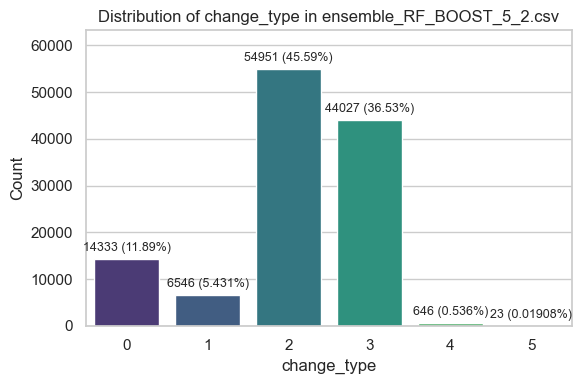

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


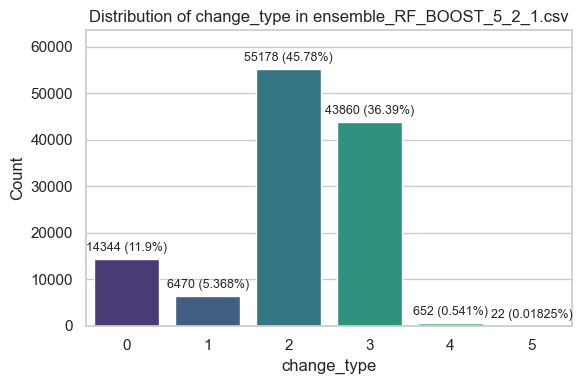

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


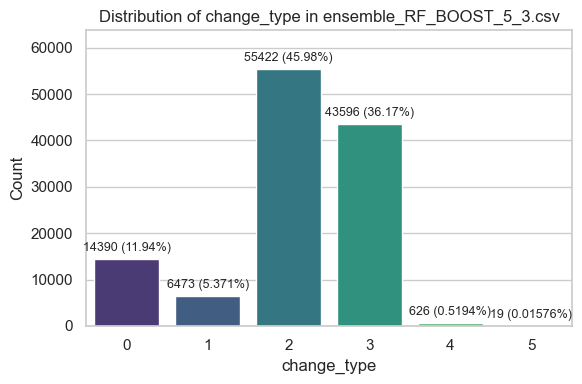

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


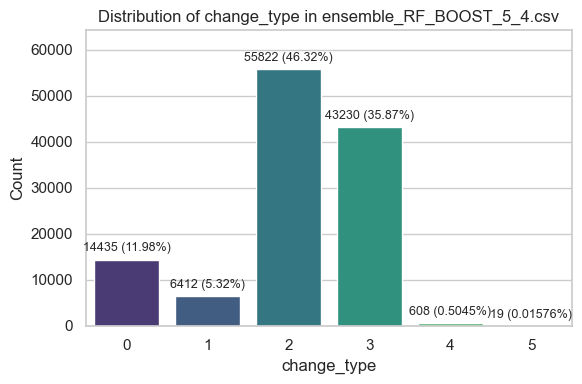

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


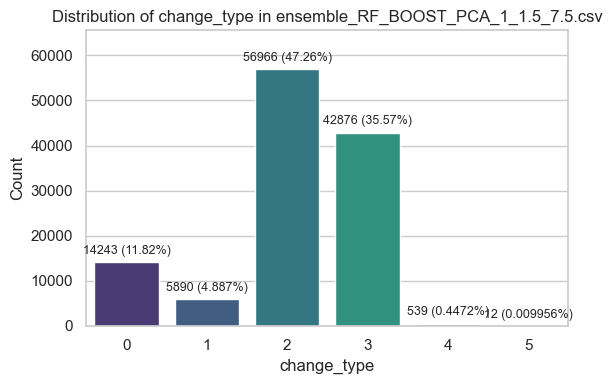

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


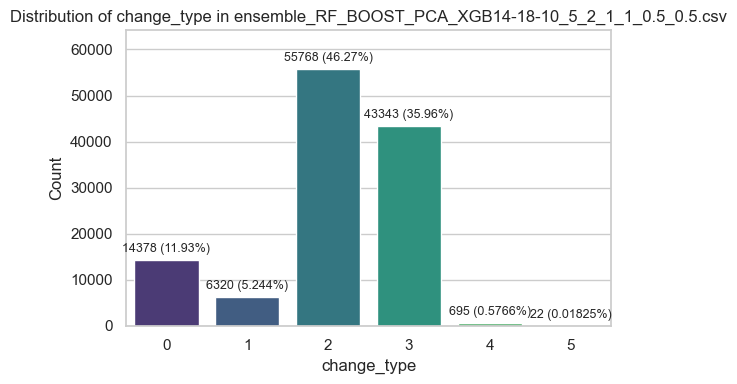

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


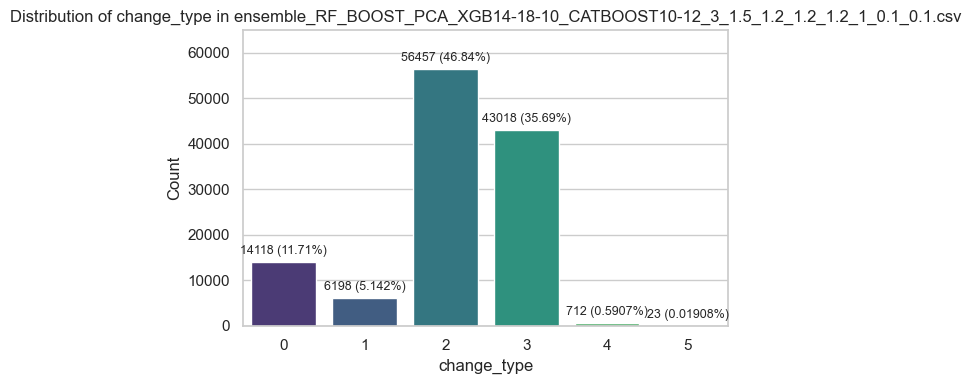

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


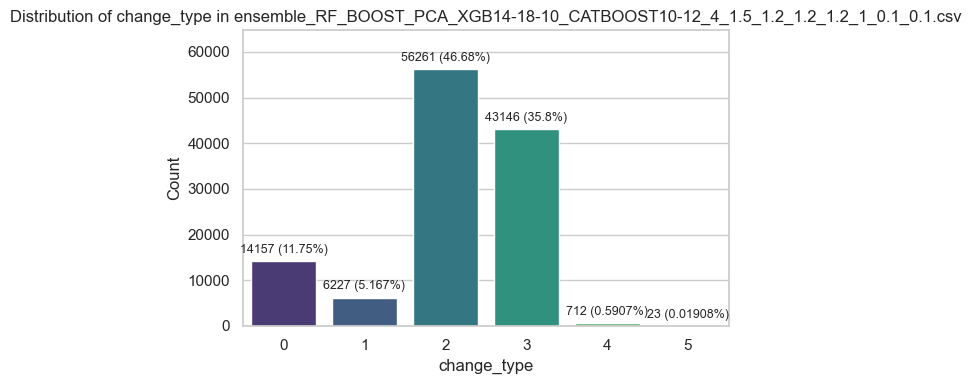

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


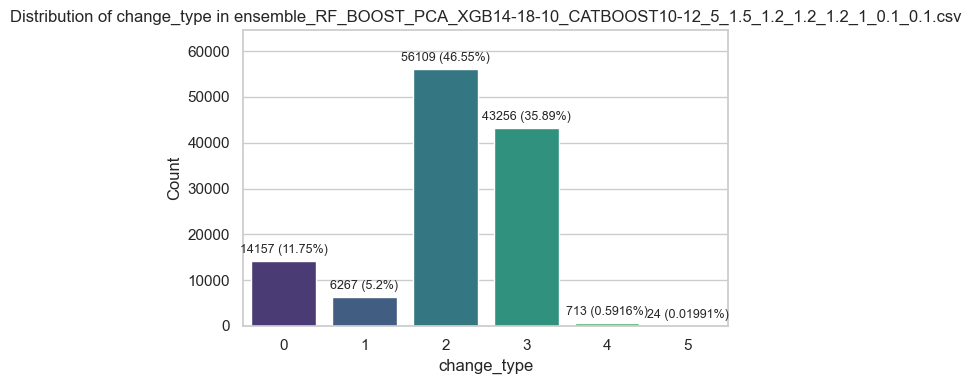

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


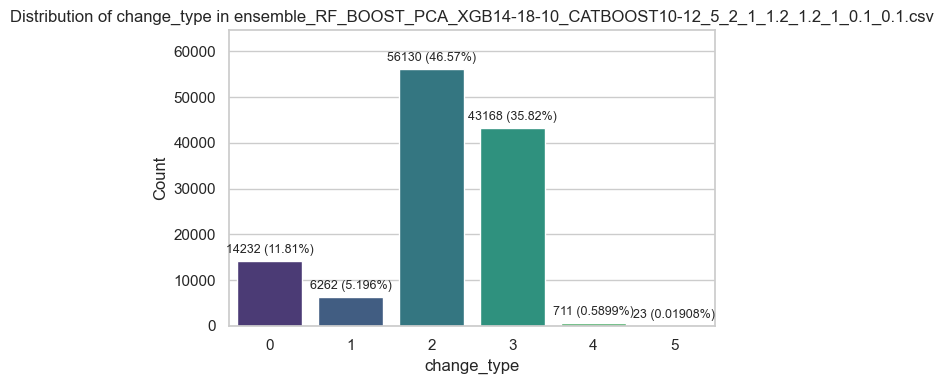

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


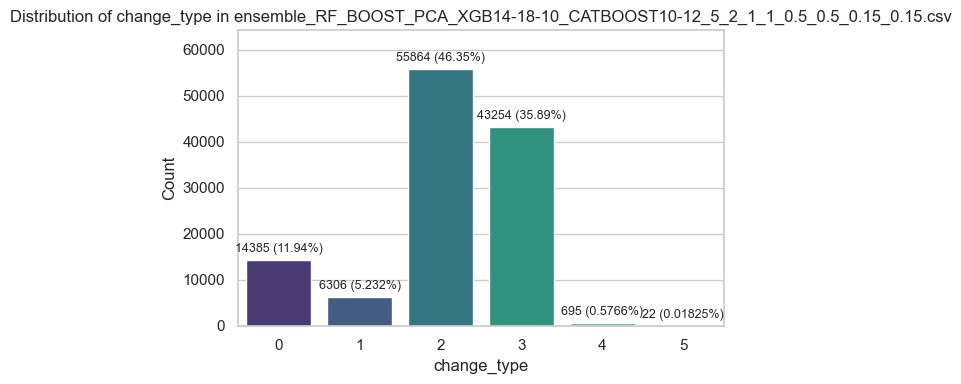

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


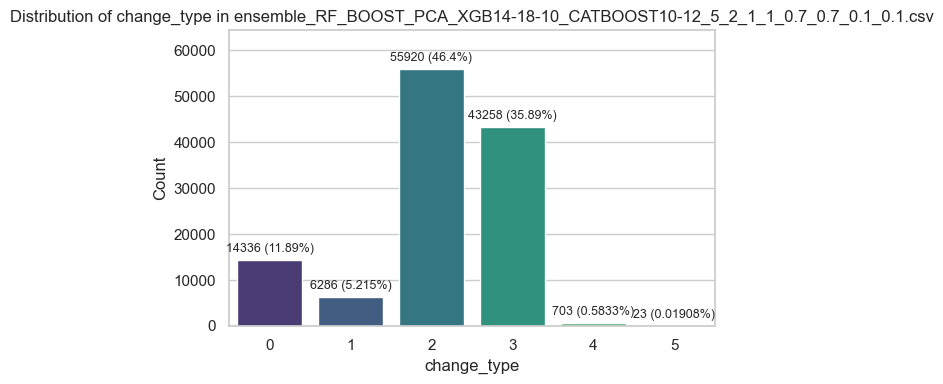

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


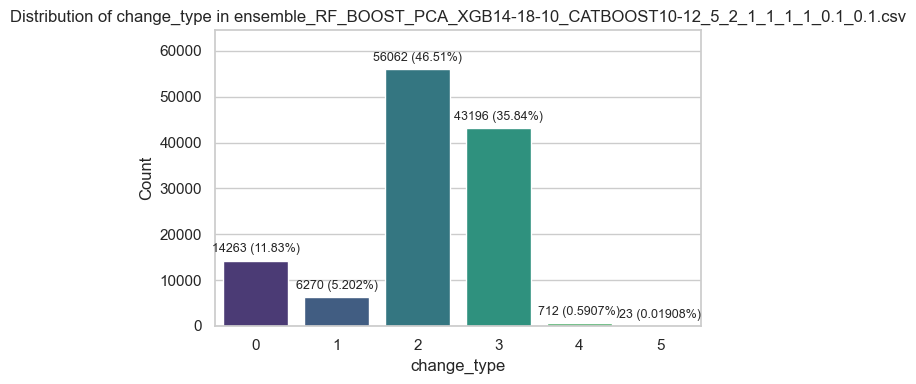

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


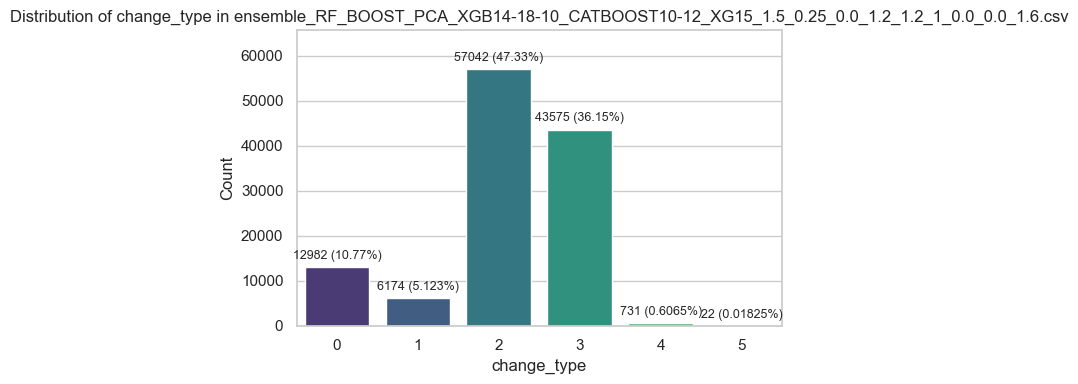

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


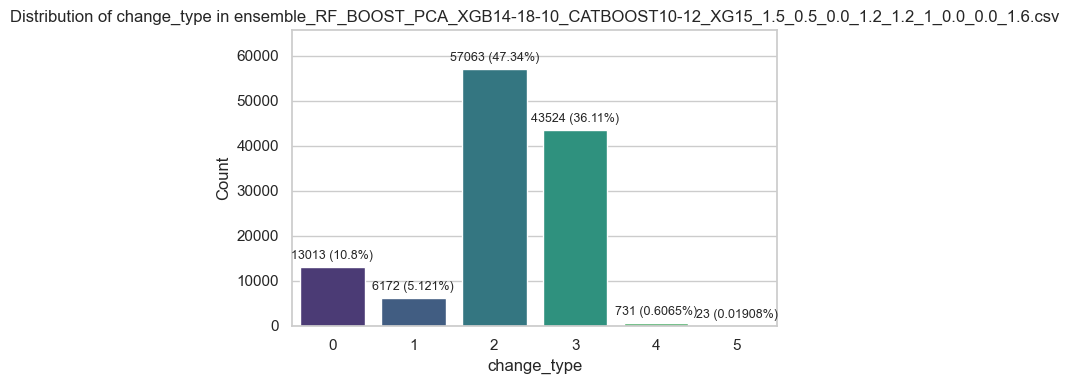

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


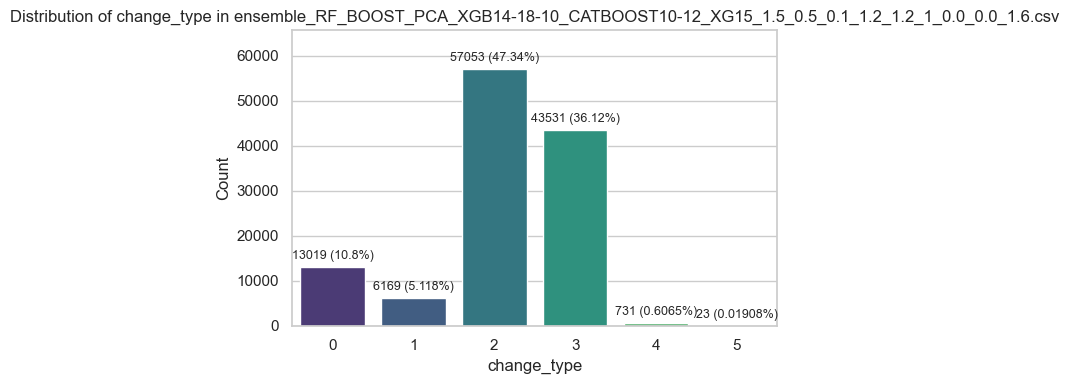

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


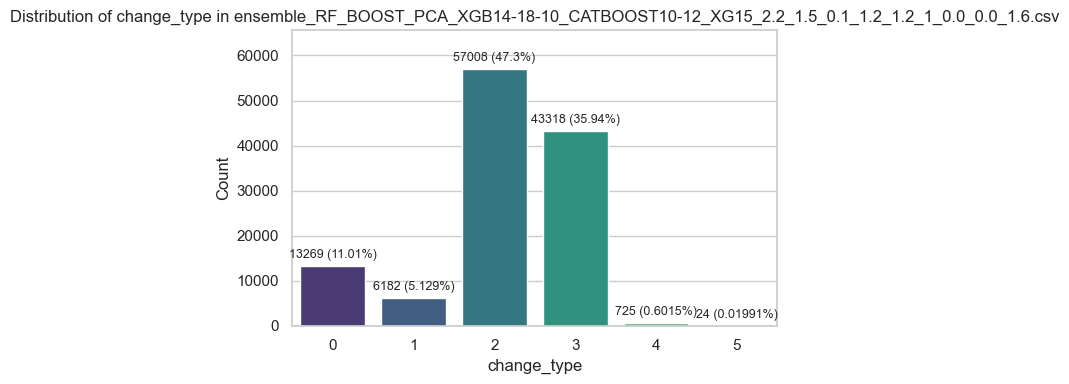

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


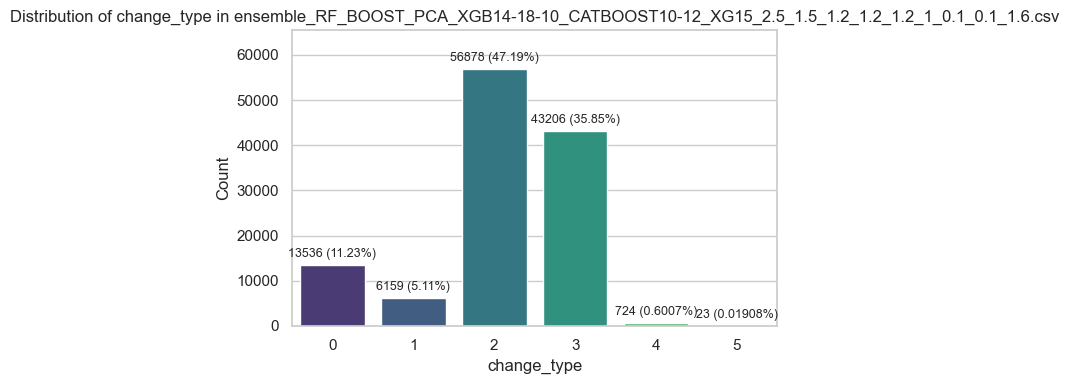

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


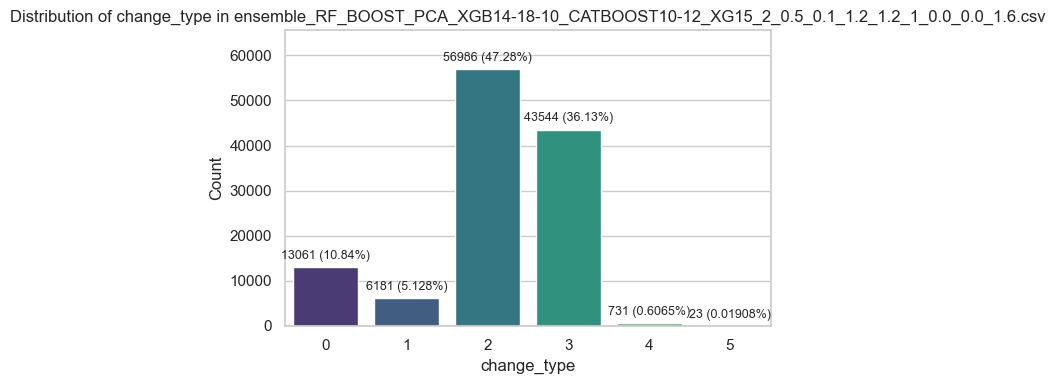

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


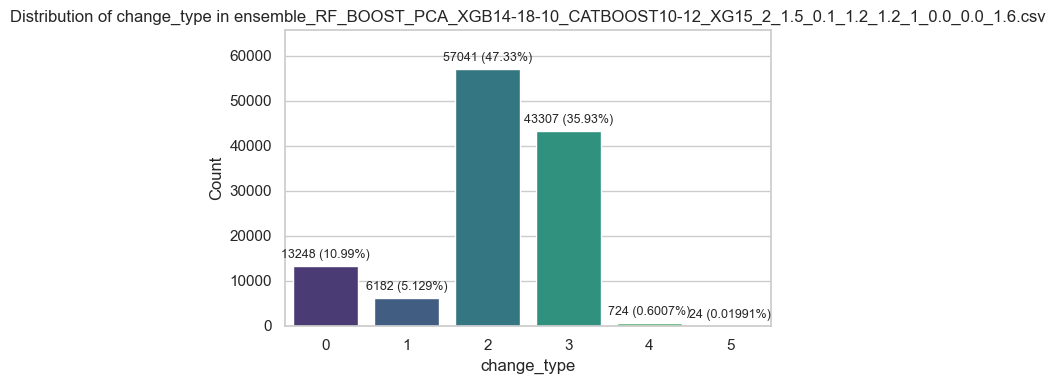

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


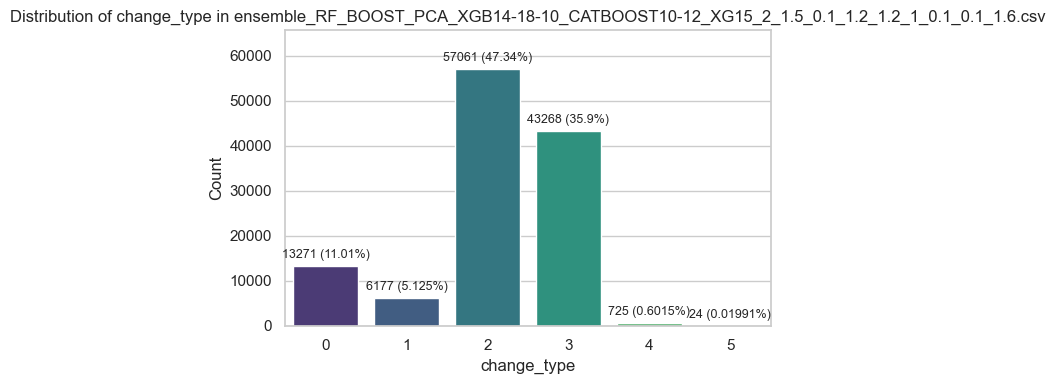

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


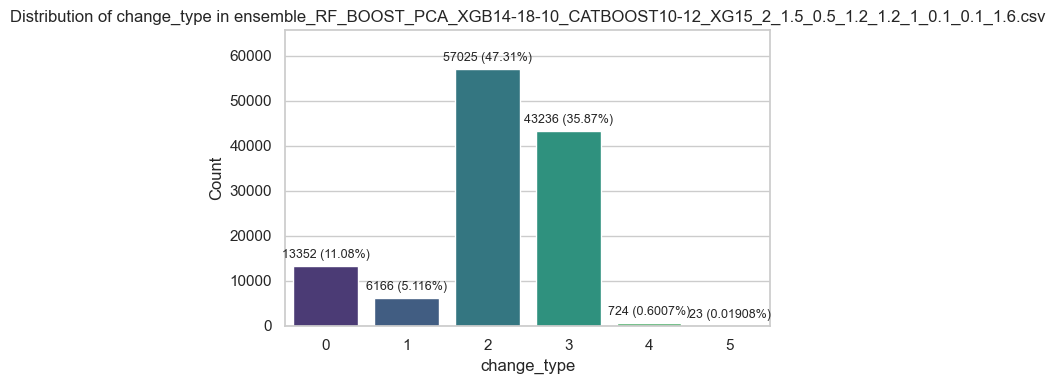

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


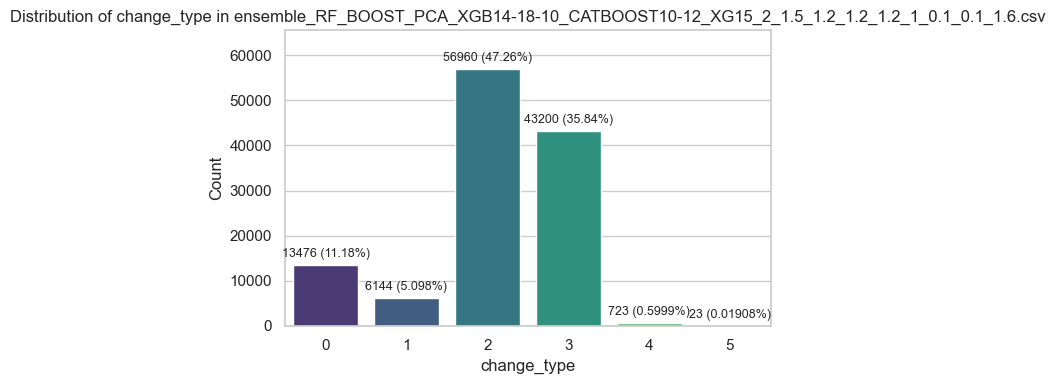

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


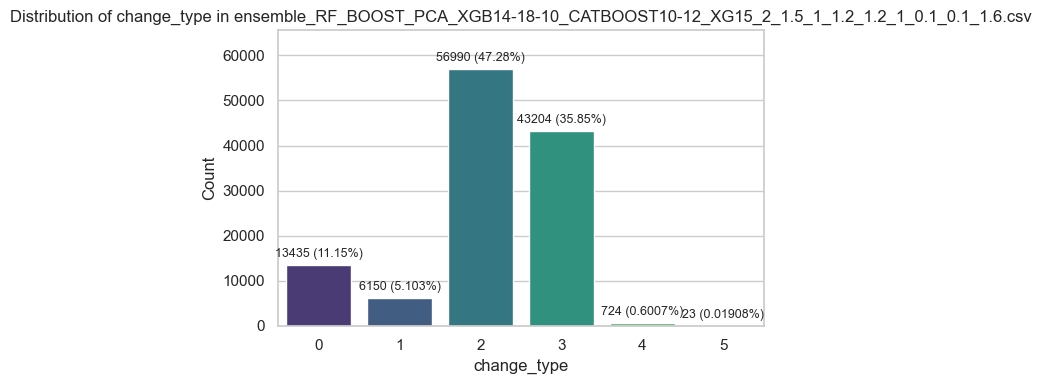

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


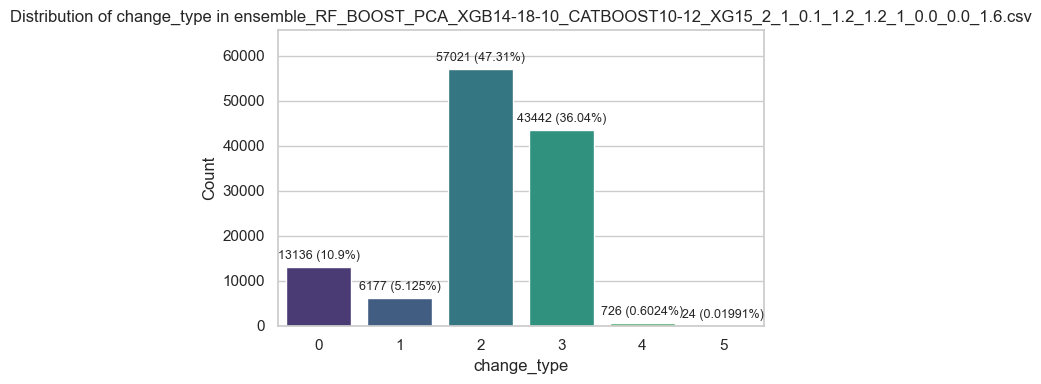

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


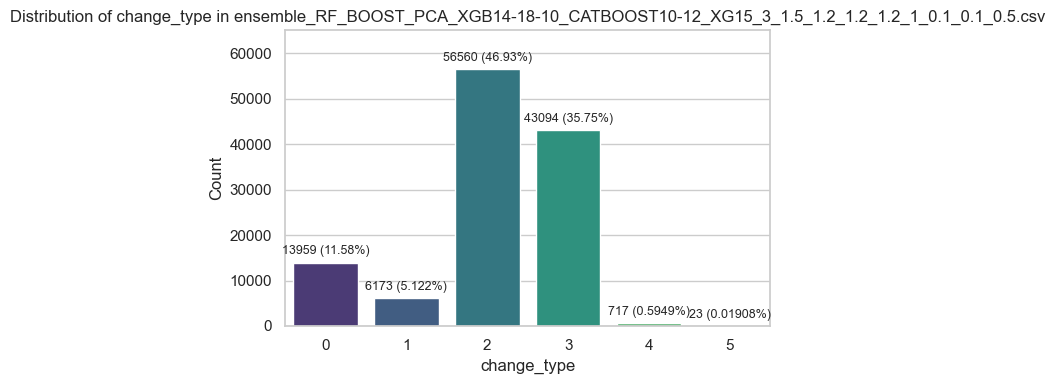

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


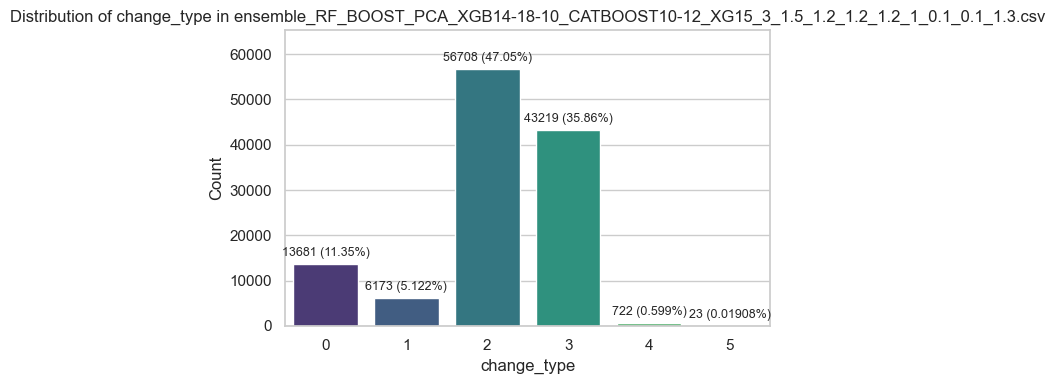

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


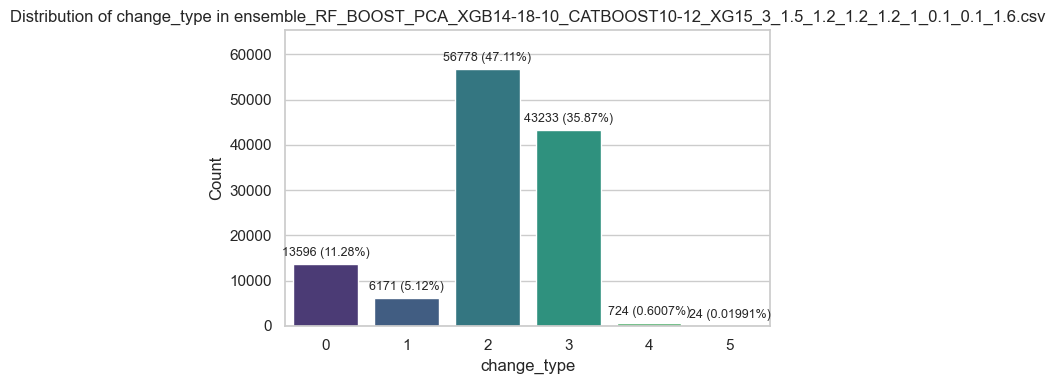

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


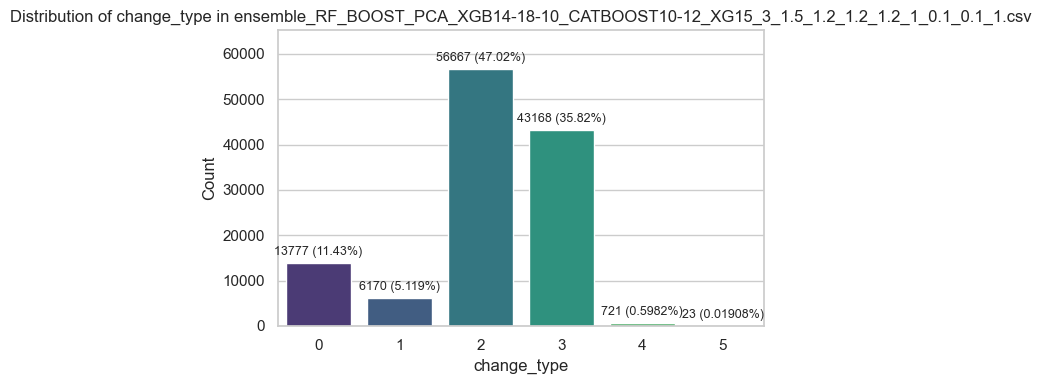

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


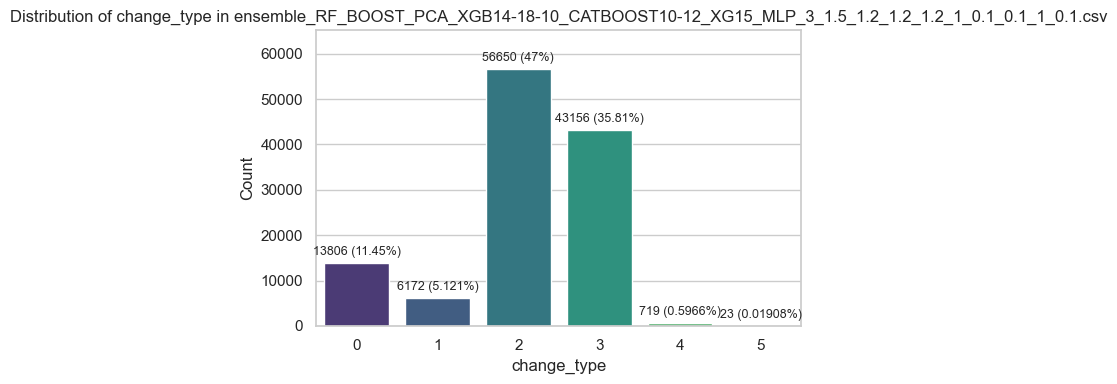

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


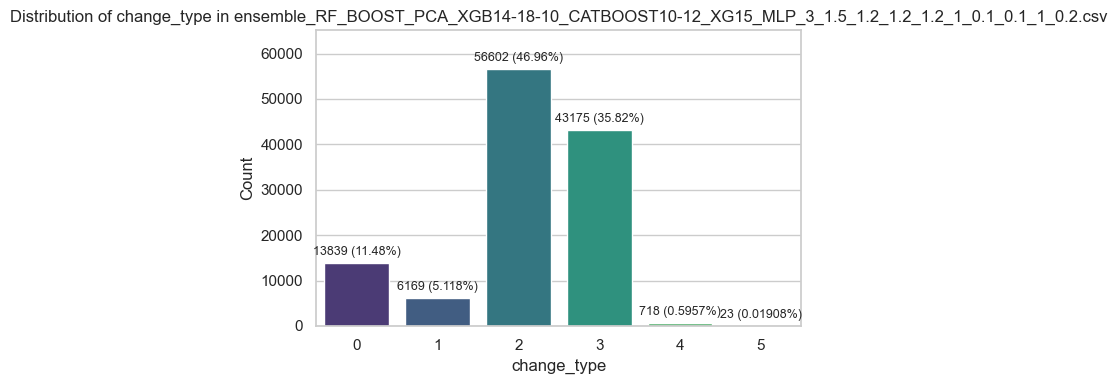

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


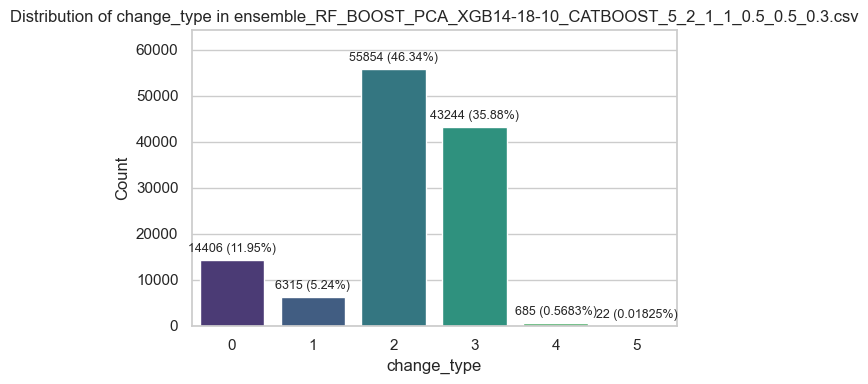

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


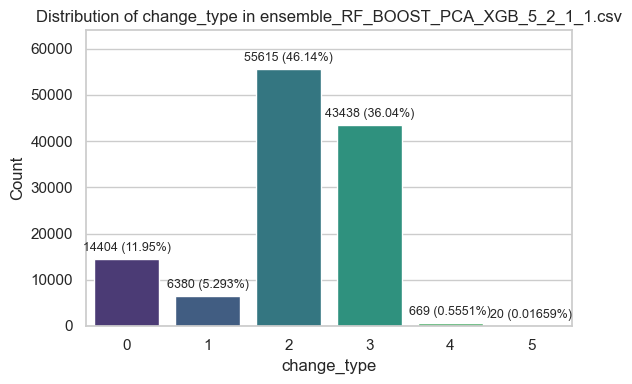

C:\Users\thier\AppData\Local\Temp\ipykernel_21860\2058494507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


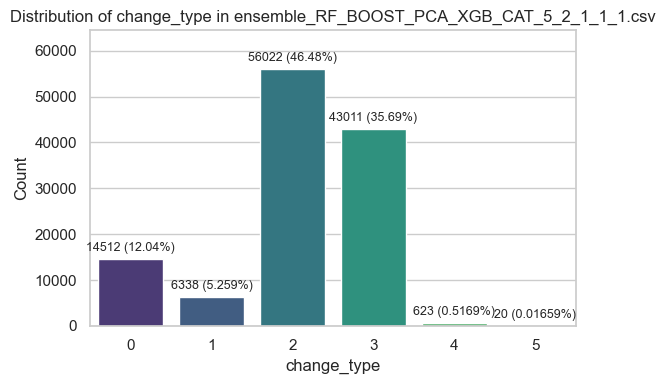

In [10]:
## Visualisation distribution des prédictions avec l'original du train
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dossier contenant les submissions
folder = "submissions_ensemble"

# Lister tous les CSV
csv_files = [f for f in os.listdir(folder) if f.endswith(".csv")]

# Style seaborn pour plots plus sympas
sns.set(style="whitegrid")

# Parcourir chaque CSV
for csv_file in csv_files:
    # Lire le CSV
    path = os.path.join(folder, csv_file)
    df = pd.read_csv(path)

    # Vérifier qu'il y a bien la colonne 'change_type'
    if "change_type" not in df.columns:
        print(f"Skipping {csv_file}: no 'change_type' column found")
        continue

    # Compter occurrences (nombre et pourcentage)
    counts = df['change_type'].value_counts().sort_index()
    percents = (counts / counts.sum()) * 100  # pourcentage
    percents = percents.map(lambda x: f"{x:.4g}%")  # 4 chiffres significatifs

    # Plot barplot
    plt.figure(figsize=(6,4))
    sns.barplot(x=counts.index, y=counts.values, palette="viridis")
    plt.title(f"Distribution of change_type in {csv_file}")
    plt.xlabel("change_type")
    plt.ylabel("Count")
    plt.ylim(0, counts.values.max() * 1.15)  # un peu d'espace pour les labels

    # Ajouter le nombre et le pourcentage sur chaque barre
    for i, (count, pct) in enumerate(zip(counts.values, percents)):
        plt.text(i, count + counts.values.max()*0.02, f"{count} ({pct})",
                 ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()


C:\Users\thier\AppData\Local\Temp\ipykernel_14112\3703632454.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


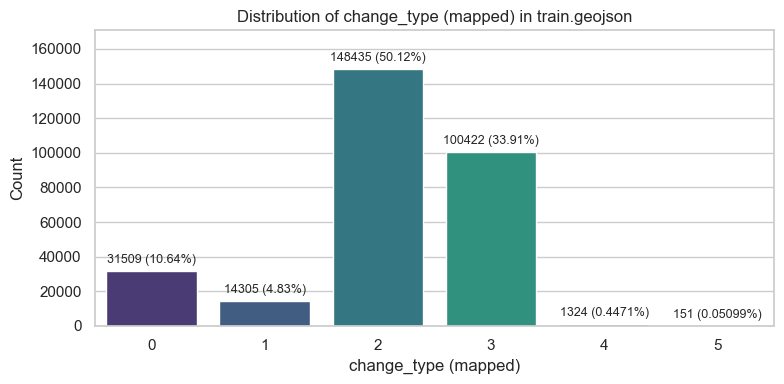

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping des change_type
change_type_map = {
    'Demolition': 0, 'Road': 1, 'Residential': 2,
    'Commercial': 3, 'Industrial': 4, 'Mega Projects': 5
}

# Charger le GeoJSON
gdf = gpd.read_file("data/train.geojson")

# Vérifier que la colonne existe
if "change_type" not in gdf.columns:
    raise ValueError("La colonne 'change_type' n'existe pas dans train.geojson")

# Remplacer les noms par les indices
gdf['change_type_mapped'] = gdf['change_type'].map(change_type_map)

# Compter occurrences (nombre et pourcentage)
counts = gdf['change_type_mapped'].value_counts().sort_index()
percents = (counts / counts.sum()) * 100
percents = percents.map(lambda x: f"{x:.4g}%")  # 4 chiffres significatifs

# Plot barplot
sns.set(style="whitegrid")
plt.figure(figsize=(8,4))
sns.barplot(x=counts.index, y=counts.values, palette="viridis")
plt.title("Distribution of change_type (mapped) in train.geojson")
plt.xlabel("change_type (mapped)")
plt.ylabel("Count")
plt.ylim(0, counts.values.max() * 1.15)

# Ajouter le nombre et le pourcentage sur chaque barre
for i, (count, pct) in enumerate(zip(counts.values, percents)):
    plt.text(i, count + counts.values.max()*0.02, f"{count} ({pct})",
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [16]:
## RF + BOOST + RF_PCA + XGB ENSEMBLE + CATBOOST
import numpy as np
import pandas as pd
import os

# ---------- 1) Config ----------
coefs = [5, 2, 1, 1, 1]  # RF, Boost, RF2, XGB, CATBOOST
vote = False    # False => weighted sum, True => vote
name = f"ensemble_RF_BOOST_PCA_XGB_CAT_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}_{coefs[4]}"
if vote:
    name = f"ensembleVOTE_RF_BOOST_PCA_XGB_CAT_{coefs[0]}_{coefs[1]}_{coefs[2]}_{coefs[3]}_{coefs[4]}"

#os.makedirs("submissions", exist_ok=True)

# ---------- 2) Load probabilities from CSVs ----------
# Si tu as fait : PROBA_rf.csv et PROBA_boost.csv
prob_rf = pd.read_csv("Proba/PROBA_rf.csv").drop(columns="Id").to_numpy()
prob_boost = pd.read_csv("Proba/PROBA_boost.csv").drop(columns="Id").to_numpy()
prob_rf2 = pd.read_csv("Proba/PROBA_rf_pca.csv").drop(columns="Id").to_numpy()
prob_xgb = pd.read_csv("Proba/PROBA_XGB_D14.csv").drop(columns="Id").to_numpy()
prob_cat = pd.read_csv("Proba/PROBA_CATBOOST.csv").drop(columns="Id").to_numpy()


# sécurité : mêmes dimensions
assert prob_rf.shape == prob_boost.shape, "RF et Boost n'ont pas la même shape"
assert prob_rf.shape == prob_rf2.shape, "RF et RF2 n'ont pas la même shape"
assert prob_rf.shape == prob_xgb.shape, "RF et XGB n'ont pas la même shape"
assert prob_rf.shape == prob_cat.shape, "RF et CAT n'ont pas la même shape"
n_classes = prob_rf.shape[1]

# ---------- 3) Predicted classes individuelles ----------
dfALL = pd.DataFrame({
    "rf": prob_rf.argmax(axis=1),
    "boost": prob_boost.argmax(axis=1),
    "rf2": prob_rf2.argmax(axis=1),
    "xgb": prob_xgb.argmax(axis=1),
    "cat": prob_cat.argmax(axis=1)
})

# ---------- 4) Ensemble ----------
if vote:
    weights = {'rf': coefs[0], 'boost': coefs[1], 'rf2': coefs[2], 'xgb': coefs[3], 'cat': coefs[4]}
    cols = []
    for col, w in weights.items():
        cols.extend([dfALL[col]] * w)
    weighted_df = pd.concat(cols, axis=1)
    dfALL[name] = weighted_df.mode(axis=1)[0].astype(int)
else:
    weighted_proba = coefs[0]*prob_rf + coefs[1]*prob_boost + coefs[2]*prob_rf2 + coefs[3]*prob_xgb + coefs[4]*prob_cat
    dfALL[name] = weighted_proba.argmax(axis=1)

# ---------- 5) Export ----------
result = dfALL[name].to_numpy()

pred_df = pd.DataFrame({
    "Id": np.arange(0, len(result)),
    "change_type": result
})

pred_df.to_csv(f"submissions_ensemble/{name}.csv", index=False)
print(f"Submission saved as submissions_ensemble/{name}.csv")


Submission saved as submissions_ensemble/ensemble_RF_BOOST_PCA_XGB_CAT_5_2_1_1_1.csv
